## 1. Import Libraries

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import numpy as np
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


## 2. Load and Explore Dataset

**Dataset:** [Natural Images](https://www.kaggle.com/datasets/prasunroy/natural-images) (Kaggle)

Contains ~6,899 images across **8 classes**: `airplane`, `car`, `cat`, `dog`, `flower`, `fruit`, `motorbike`, `person`.
Images are of varying sizes and aspect ratios resizing is required during preprocessing.
The dataset has no pre-defined train/test split, so I split it ourselves (70% train / 15% validation / 15% test).

In [2]:
import kagglehub
path = kagglehub.dataset_download("prasunroy/natural-images")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/prasunroy/natural-images


In [3]:
import os

# The dataset folder structure: path/natural_images/<class_name>/*.jpg
DATA_DIR = os.path.join(path, "natural_images")
assert os.path.isdir(DATA_DIR), f"Directory not found: {DATA_DIR}"

classes = sorted(os.listdir(DATA_DIR))
print("Classes:", classes)
print("Number of classes:", len(classes))

# Per-class image counts
for c in classes:
    count = len(os.listdir(os.path.join(DATA_DIR, c)))
    print(f"  {c:12s}: {count} images")

Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Number of classes: 8
  airplane    : 727 images
  car         : 968 images
  cat         : 885 images
  dog         : 702 images
  flower      : 843 images
  fruit       : 1000 images
  motorbike   : 788 images
  person      : 986 images


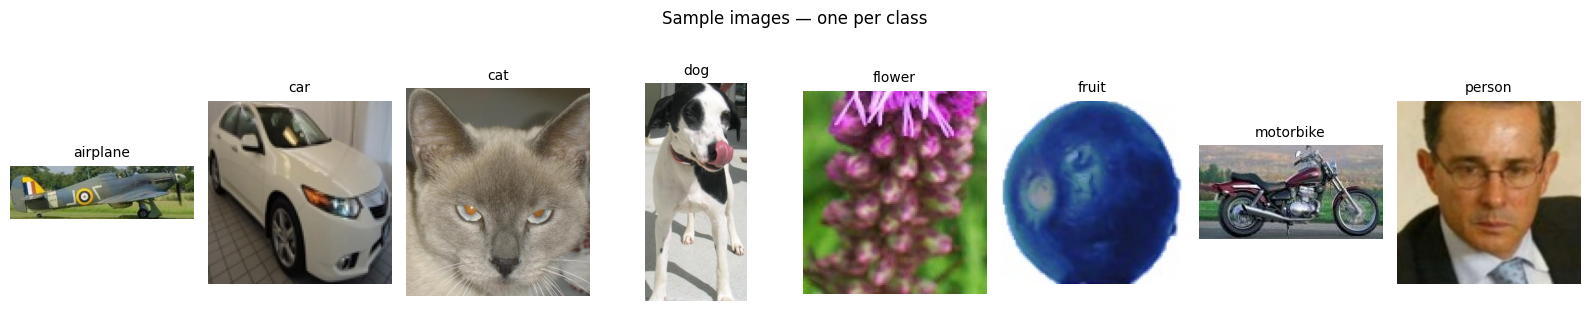

In [4]:
# Display one sample image per class
fig, axes = plt.subplots(1, len(classes), figsize=(16, 3))
for ax, c in zip(axes, classes):
    class_dir = os.path.join(DATA_DIR, c)
    sample = os.listdir(class_dir)[0]
    img = plt.imread(os.path.join(class_dir, sample))
    ax.imshow(img)
    ax.set_title(c, fontsize=10)
    ax.axis("off")
plt.suptitle("Sample images — one per class", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Augmentation

- **Training:** Random horizontal flip, rotation (±15°), and color jitter for augmentation to reduce overfitting on a relatively small dataset (~4,800 training images).
- **Validation/Test:** Only resize and convert to tensor no augmentation on evaluation data.
- Images resized to **128×128** to keep training fast while preserving enough detail for 8 class classification.
- No ImageNet normalization since I am training from scratch (the model learns its own feature scale).

In [5]:
size = 128

train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
])

In [6]:
# Load full dataset, then split into train / val / test (70 / 15 / 15)
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
NUM_CLASSES = len(full_dataset.classes)
print("Classes:", full_dataset.classes)

total = len(full_dataset)
n_test = int(total * 0.15)
n_val = int(total * 0.15)
n_train = total - n_val - n_test

generator = torch.Generator().manual_seed(42)
train_set, val_set, test_set = random_split(full_dataset, [n_train, n_val, n_test], generator=generator)

# Override transforms for val and test subsets so they don't get augmentation
val_dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

val_set_clean = torch.utils.data.Subset(val_dataset, val_set.indices)
test_set_clean = torch.utils.data.Subset(test_dataset, test_set.indices)

print(f"Train: {len(train_set)} | Val: {len(val_set_clean)} | Test: {len(test_set_clean)}")

Classes: ['airplane', 'car', 'cat', 'dog', 'flower', 'fruit', 'motorbike', 'person']
Train: 4831 | Val: 1034 | Test: 1034


## 4. Define CNN Architecture

Custom CNN with **3 convolutional blocks**, each containing two `Conv2d` layers followed by `BatchNorm2d`, `ReLU`, `MaxPool2d`, and `Dropout2d`.

**Architecture justification:**
- **Dual Conv per block:** Two consecutive convolutions before pooling capture richer spatial features than a single conv layer, without adding the depth/cost of a full residual block.
- **Progressive filter increase (32 → 64 → 128):** Matches the standard practice of extracting more abstract features at deeper layers.
- **Increasing Dropout2d (0.1 → 0.2 → 0.3):** Applies stronger regularization at deeper layers where overfitting risk is higher. Additional `Dropout(0.4)` before the final FC layer.
- **AdaptiveAvgPool2d:** Makes the classifier independent of exact spatial dimensions, so changing `size` doesn't break the model.
- **8 output neurons:** One per class, fed to `CrossEntropyLoss`.

In [7]:
#important HyperParameters
batch_size = 32
learning_rate = 0.001
minimum_learning_rate = 1e-4
epochs = 25

In [8]:
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set_clean, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set_clean, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [9]:
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

class CNNModel(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(CNNModel, self).__init__()
        # Feature extraction layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),
        )

        # Classification layers
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 1. Get the Model
model = CNNModel(num_classes=NUM_CLASSES).to(device)
# 2. Define optimizer
optimizer = Adam(model.parameters(), lr=learning_rate)
# 3. Define LR scheduler
scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=minimum_learning_rate)
# 4. Define loss function
criterion = nn.CrossEntropyLoss()

from torchsummary import summary
summary(model, input_size=(3, size, size));

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,928
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-14           [-1, 64,

## 5. Training Loop with Validation

In [10]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(loader)
    train_acc = correct / total
    return train_loss, train_acc


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = total_loss / len(loader)
    val_acc = correct / total
    return val_loss, val_acc

In [11]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(epochs):
    print(f"----------------------------------------------------")
    print(f"Epoch {epoch+1}/{epochs}, LR: {optimizer.param_groups[0]['lr']:.6g}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  -> Saved best model (val_acc={val_acc:.4f})")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# Load best checkpoint before evaluation
model.load_state_dict(torch.load("best_model.pth"))
print("Loaded best model checkpoint.")

----------------------------------------------------
Epoch 1/25, LR: 0.001
Train Loss: 0.9470 | Train Acc: 0.6669
Val Loss:   0.4645 | Val Acc:   0.8346
  -> Saved best model (val_acc=0.8346)
----------------------------------------------------
Epoch 2/25, LR: 0.000996452
Train Loss: 0.6205 | Train Acc: 0.7742
Val Loss:   0.4309 | Val Acc:   0.8366
  -> Saved best model (val_acc=0.8366)
----------------------------------------------------
Epoch 3/25, LR: 0.000985862
Train Loss: 0.5264 | Train Acc: 0.8079
Val Loss:   0.3869 | Val Acc:   0.8520
  -> Saved best model (val_acc=0.8520)
----------------------------------------------------
Epoch 4/25, LR: 0.000968399
Train Loss: 0.4490 | Train Acc: 0.8363
Val Loss:   0.2610 | Val Acc:   0.9072
  -> Saved best model (val_acc=0.9072)
----------------------------------------------------
Epoch 5/25, LR: 0.000944338
Train Loss: 0.4086 | Train Acc: 0.8520
Val Loss:   0.4475 | Val Acc:   0.8250
----------------------------------------------------
Ep

## 6. Visualizations (Loss & Accuracy Curves)

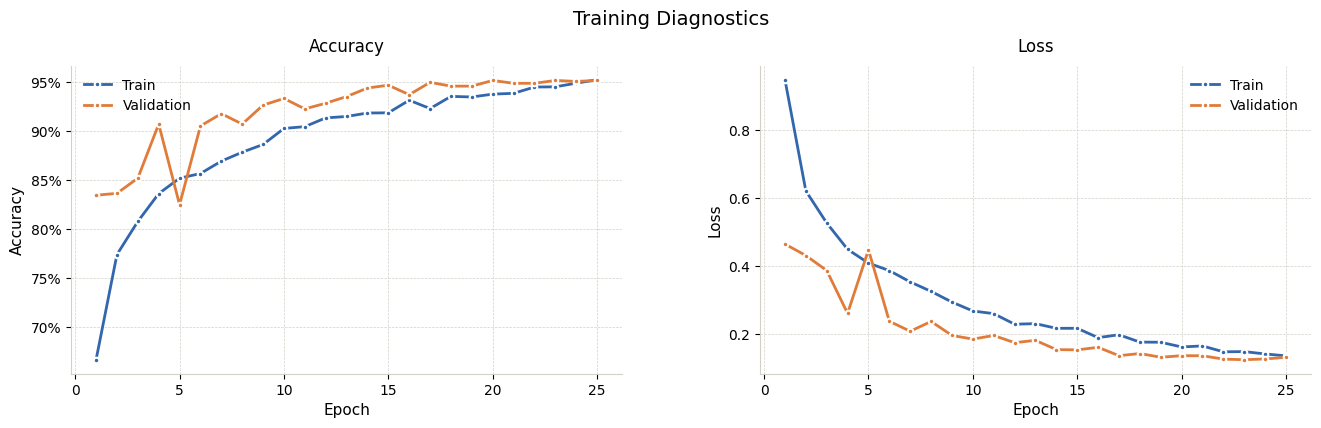

In [24]:
BLUE   = "#3266ad"
ORANGE = "#e07b39"
BLACK  = "#000000"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#d3d1c7",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#d3d1c7",
    "grid.linewidth": 0.5,
    "grid.linestyle": "--",
    "xtick.color": BLACK,
    "ytick.color": BLACK,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

epochs_range = np.arange(1, epochs + 1)
fig = plt.figure(figsize=(16, 4))
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.25)

# Accuracy
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs_range, train_accuracies, color=BLUE, lw=2, label="Train", marker="o", ms=4, mew=1.5, mec="white")
ax1.plot(epochs_range, val_accuracies, color=ORANGE, lw=2, label="Validation", marker="o", ms=4, mew=1.5, mec="white")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.set_title("Accuracy", fontsize=12, fontweight="medium", pad=10)
ax1.legend(frameon=False, fontsize=10)

# Loss
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs_range, train_losses, color=BLUE, lw=2, label="Train", marker="o", ms=4, mew=1.5, mec="white")
ax2.plot(epochs_range, val_losses, color=ORANGE, lw=2, label="Validation", marker="o", ms=4, mew=1.5, mec="white")
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Loss", fontsize=11)
ax2.set_title("Loss", fontsize=12, fontweight="medium", pad=10)
ax2.legend(frameon=False, fontsize=10)

fig.suptitle("Training Diagnostics", fontsize=14, fontweight="medium", y=1.02)
# plt.tight_layout()
plt.show()

## 7. Evaluate Model on Test Set

In [13]:
class_names = full_dataset.classes

model.eval()
misclassified = []
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        for img, true, pred in zip(images, labels, preds):
            if true != pred:
                misclassified.append((img.cpu(), true.cpu(), pred.cpu()))

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

Test Accuracy: 0.9449

              precision    recall  f1-score   support

    airplane     0.9327    0.9700    0.9510       100
         car     0.9740    0.9934    0.9836       151
         cat     0.8645    0.8645    0.8645       155
         dog     0.7941    0.7642    0.7788       106
      flower     0.9925    0.9565    0.9742       138
       fruit     1.0000    1.0000    1.0000       133
   motorbike     0.9840    0.9919    0.9880       124
      person     0.9922    1.0000    0.9961       127

    accuracy                         0.9449      1034
   macro avg     0.9418    0.9426    0.9420      1034
weighted avg     0.9444    0.9449    0.9445      1034



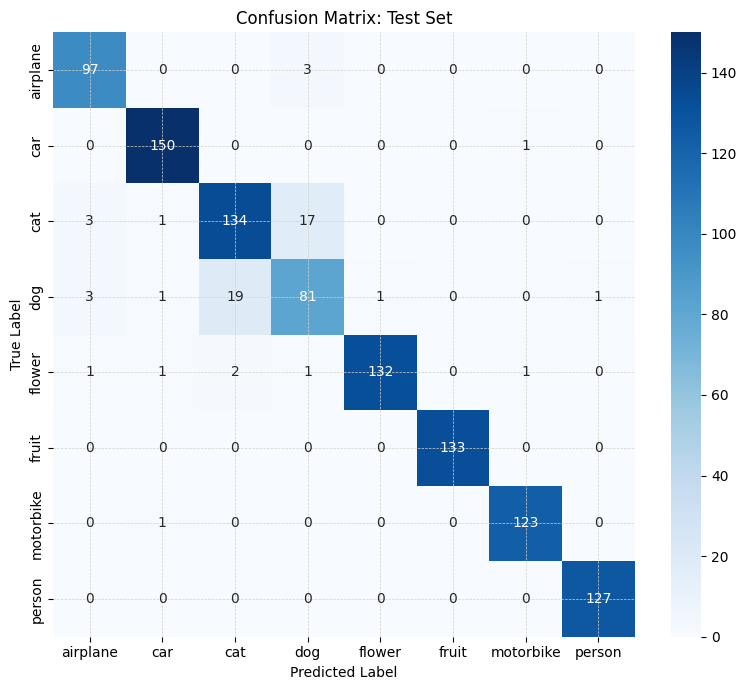

In [26]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Test Set')
plt.tight_layout()
plt.show()

    class  precision   recall       f1  support
    fruit   1.000000 1.000000 1.000000      133
   person   0.992188 1.000000 0.996078      127
motorbike   0.984000 0.991935 0.987952      124
      car   0.974026 0.993377 0.983607      151
   flower   0.992481 0.956522 0.974170      138
 airplane   0.932692 0.970000 0.950980      100
      cat   0.864516 0.864516 0.864516      155
      dog   0.794118 0.764151 0.778846      106

Best-performing class:  fruit (F1 = 1.0000)
Worst-performing class: dog (F1 = 0.7788)


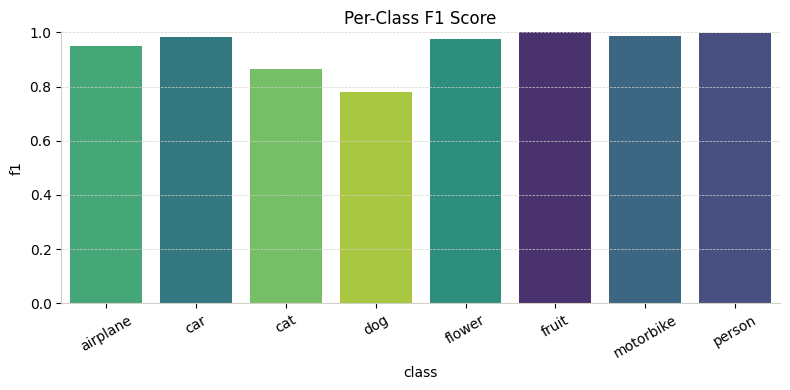

In [15]:
# Per-class F1 analysis — best and worst performing classes
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=range(NUM_CLASSES)
)

import pandas as pd
per_class = pd.DataFrame({
    "class": class_names,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
}).sort_values("f1", ascending=False)

print(per_class.to_string(index=False))

best = per_class.iloc[0]
worst = per_class.iloc[-1]
print(f"\nBest-performing class:  {best['class']} (F1 = {best['f1']:.4f})")
print(f"Worst-performing class: {worst['class']} (F1 = {worst['f1']:.4f})")

plt.figure(figsize=(8, 4))
sns.barplot(data=per_class, x="class", y="f1", hue="class", palette="viridis",
            order=class_names, legend=False)
plt.title("Per-Class F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Total misclassified: 57


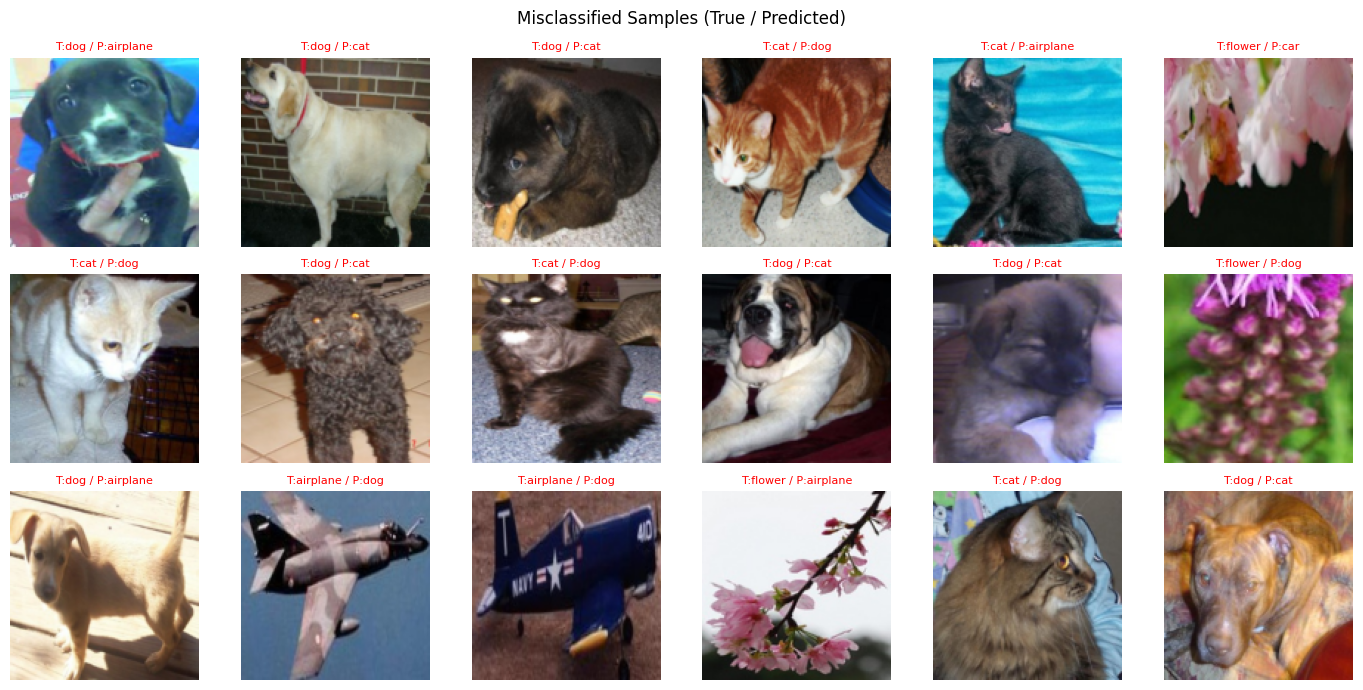

In [16]:
# Display misclassified samples
print(f"Total misclassified: {len(misclassified)}")
num_rows = 3
num_cols = 6
num_show = min(num_rows * num_cols, len(misclassified))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < num_show:
        img, true, pred = misclassified[i]
        img_np = img.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        ax.imshow(img_np)
        ax.set_title(f"T:{class_names[true]} / P:{class_names[pred]}", fontsize=8, color="red")
    ax.axis("off")
plt.suptitle("Misclassified Samples (True / Predicted)", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Analysis & Discussion

**Overall Performance:**
The model achieved a test accuracy of 94.49% with a macro F1 of 0.9420 across 1,034 test images. Training ran for all 25 epochs, with the best checkpoint saved at epoch 20 (val_acc = 0.9516). By the final epoch, train accuracy reached 95.24% against a validation accuracy of 95.16% that gap of less than 1% indicates overfitting is well-controlled. The combination of progressive Dropout2d, data augmentation, and CosineAnnealingLR decay (from 0.001 down to ~0.0001) worked effectively together.

**Best-Performing Class:**
`fruit` achieved a perfect F1 of 1.0000 (precision 1.0, recall 1.0, zero misclassifications). This is expected: fruits have distinctive color, texture, and shape patterns that don't overlap with any other class in the dataset. `person` (F1 = 0.9961) and `motorbike` (F1 = 0.9880) also performed very strongly for similar reasons their visual features are highly distinctive.

**Worst-Performing Class:**
`dog` was the weakest class at F1 = 0.7789 (precision 0.7941, recall 0.7642), well below every other class. The second-worst, `cat` (F1 = 0.8645), is the obvious confusion partner both are furry animals with similar body shapes, textures, and typical backgrounds. The confusion matrix confirms this: dog and cat images are the primary source of the 57 total misclassifications. This is a known hard pair even for deeper networks the features that distinguish them (facial structure, ear shape) require finer spatial detail than what a 128×128 input and three conv blocks can reliably capture.

**Effect of Regularization:**
The train/val curves converged closely with no sign of divergence, indicating the regularization stack was appropriate for this dataset size. CosineAnnealingLR's smooth decay helped particularly in epochs 14–20 where the model continued to make small gains on validation accuracy rather than oscillating contrasted with epoch 5 where val_acc dropped to 0.8250 while the LR was still relatively high (0.000944). The model file size is 3.28 MB, well under the 20 MB upload limit.

**Limitations:**
The dataset is small (~6,900 total images, ~4,800 for training), which limits what a from scratch CNN can learn. The 128×128 downsampling discards fine-grained texture detail that could help distinguish cat from dog. No pretrained backbone was used transfer learning would likely push accuracy above 97% on this dataset.

## 9. Save Trained Model

In [17]:
MODEL_PATH = "cnn_natural_images.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")
print(f"File size: {os.path.getsize(MODEL_PATH) / 1e6:.2f} MB")

Model saved to: cnn_natural_images.pth
File size: 3.28 MB


In [18]:
# Verify: reload model and check test accuracy matches
saved_model = CNNModel(num_classes=NUM_CLASSES).to(device)
saved_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
saved_model.eval()

summary(saved_model, input_size=(3, size, size))

# Quick sanity check
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = saved_model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print(f"\nReloaded model test accuracy: {correct/total:.4f}")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,248
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              ReLU-6         [-1, 32, 128, 128]               0
         MaxPool2d-7           [-1, 32, 64, 64]               0
         Dropout2d-8           [-1, 32, 64, 64]               0
            Conv2d-9           [-1, 64, 64, 64]          18,496
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,928
      BatchNorm2d-13           [-1, 64, 64, 64]             128
             ReLU-14           [-1, 64,

## 10. Conclusions & Future Work

**Conclusions:**
The custom 3-block CNN with 815,016 trainable parameters reached 94.49% test accuracy and 0.9420 macro F1 on the Natural Images dataset (8 classes), trained in 25 epochs. Six out of eight classes exceeded 0.95 F1, with `fruit` achieving perfect classification and `person`/`motorbike`/`car` all above 0.98. The main weakness is the dog cat confusion pair (dog F1 = 0.7789, cat F1 = 0.8645), which accounts for the majority of errors. The close train/val accuracy gap (~0.1%) confirms that the regularization strategy progressive Dropout2d (0.1 → 0.2 → 0.3), classifier Dropout (0.4), augmentation, and cosine LR decay prevented overfitting despite the small dataset size.

**Future Work:**
- Transfer learning with a pretrained ResNet18 or EfficientNet backbone to establish an accuracy upper bound, particularly for the dog/cat pair where learned low level features from ImageNet would help.
- Higher input resolution (e.g., 224×224) to preserve the fine grained texture detail that separates cats from dogs.
- Grad-CAM visualization on misclassified dog/cat samples to verify whether the model is attending to discriminative regions (face, ears) or irrelevant background.
- Hyperparameter search over dropout rate and number of conv blocks the current architecture may be slightly underfit given that train and val accuracy essentially matched by the end.